# Image Quality Metrics — All Severity Variants

Extended version of `ARC_ATLAS_Image_Quality_Metrics.ipynb` that covers
**all 5 severity variants** (v1–v5) for each of the 5 downsampling methods
(25 degraded datasets + 2 reference sets = 27 total).

| Cells | Purpose |
|-------|--------|
| 1 | Paths + DATASETS config (27 variants) |
| 2 | IQM function definitions (FWHM, HFE, LapVar) |
| 3 | Run computation → `image_quality_metrics_all_variants_<ts>.csv` |
| 4+ | Summary stats, visualisations, perilesional analysis |

> Missing variant directories are silently skipped. Run the downsampling cells first.

# Image Quality Metrics

Computes three sharpness/blur proxies on **each preprocessed test image** across all variants:

| Metric | Direction | Meaning |
|---|---|---|
| `fwhm_mm` | lower = sharper | Whole-brain Gaussian FWHM blur estimate |
| `hi_freq_energy` | higher = sharper | Fraction of spectral power above 0.25 Nyquist |
| `lap_var` | higher = sharper | Variance of Laplacian (edge strength) |

**Variants evaluated:**
- `test_hires` — natural high-quality images (138 subjects)
- `test_lores` — natural low-quality images (198 subjects)
- `Crude` — isotropic downsampling to 3 mm, resampled back to 1 mm
- `ThickSlices` — thick axial slices (3 mm z), resampled back
- `InPlaneCoarse` — in-plane coarsening (3x3x1 mm), resampled back
- `ReducedSNR` — Gaussian noise added in k-space
- `RigidJitter` — random rigid slice jitter

**Output:** `image_quality_metrics_all_variants_<timestamp>.csv` saved in this folder.


In [29]:
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
from numpy.fft import fftn, fftshift
from scipy.ndimage import laplace
from joblib import Parallel, delayed
import datetime

# ── Paths ─────────────────────────────────────────────────────────────────────
BASE       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined")
SPLIT_BASE = BASE / "A_A_Combined_Data/Processed_HiresLowres_Split_Data"
DOWN_BASE  = BASE / "A_A_Combined_Data/Downsampled_Data"
OUT_DIR    = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")

# ── Dataset configs — all variants (v1-v5) per method ──────────────────────────
DATASETS = [
    # Reference sets
    {"variant": "test_hires",         "t1_dir": SPLIT_BASE / "test_hires/t1"},
    {"variant": "test_lores",         "t1_dir": SPLIT_BASE / "test_lores/t1"},
    # Crude variants
    {"variant": "Crude_v1",           "t1_dir": DOWN_BASE / "Crude/t1"},
    {"variant": "Crude_v2",           "t1_dir": DOWN_BASE / "Crude_v2/t1"},
    {"variant": "Crude_v3",           "t1_dir": DOWN_BASE / "Crude_v3/t1"},
    {"variant": "Crude_v4",           "t1_dir": DOWN_BASE / "Crude_v4/t1"},
    {"variant": "Crude_v5",           "t1_dir": DOWN_BASE / "Crude_v5/t1"},
    # ThickSlices variants
    {"variant": "ThickSlices_v1",     "t1_dir": DOWN_BASE / "ThickSlices/t1"},
    {"variant": "ThickSlices_v2",     "t1_dir": DOWN_BASE / "ThickSlices_v2/t1"},
    {"variant": "ThickSlices_v3",     "t1_dir": DOWN_BASE / "ThickSlices_v3/t1"},
    {"variant": "ThickSlices_v4",     "t1_dir": DOWN_BASE / "ThickSlices_v4/t1"},
    {"variant": "ThickSlices_v5",     "t1_dir": DOWN_BASE / "ThickSlices_v5/t1"},
    # InPlaneCoarse variants
    {"variant": "InPlaneCoarse_v1",   "t1_dir": DOWN_BASE / "InPlaneCoarse/t1"},
    {"variant": "InPlaneCoarse_v2",   "t1_dir": DOWN_BASE / "InPlaneCoarse_v2/t1"},
    {"variant": "InPlaneCoarse_v3",   "t1_dir": DOWN_BASE / "InPlaneCoarse_v3/t1"},
    {"variant": "InPlaneCoarse_v4",   "t1_dir": DOWN_BASE / "InPlaneCoarse_v4/t1"},
    {"variant": "InPlaneCoarse_v5",   "t1_dir": DOWN_BASE / "InPlaneCoarse_v5/t1"},
    # ReducedSNR variants
    {"variant": "ReducedSNR_v1",      "t1_dir": DOWN_BASE / "ReducedSNR/t1"},
    {"variant": "ReducedSNR_v2",      "t1_dir": DOWN_BASE / "ReducedSNR_v2/t1"},
    {"variant": "ReducedSNR_v3",      "t1_dir": DOWN_BASE / "ReducedSNR_v3/t1"},
    {"variant": "ReducedSNR_v4",      "t1_dir": DOWN_BASE / "ReducedSNR_v4/t1"},
    {"variant": "ReducedSNR_v5",      "t1_dir": DOWN_BASE / "ReducedSNR_v5/t1"},
    # RigidJitter variants
    {"variant": "RigidJitter_v1",     "t1_dir": DOWN_BASE / "RigidJitter/t1"},
    {"variant": "RigidJitter_v2",     "t1_dir": DOWN_BASE / "RigidJitter_v2/t1"},
    {"variant": "RigidJitter_v3",     "t1_dir": DOWN_BASE / "RigidJitter_v3/t1"},
    {"variant": "RigidJitter_v4",     "t1_dir": DOWN_BASE / "RigidJitter_v4/t1"},
    {"variant": "RigidJitter_v5",     "t1_dir": DOWN_BASE / "RigidJitter_v5/t1"},
]

N_JOBS = 12

# Verify all paths (skip missing variant dirs — they may not be generated yet)
print(f"{'Variant':<22} {'Status':<9} {'N T1s':>6}")
print("-" * 42)
for ds in DATASETS:
    p = ds["t1_dir"]
    status = "OK" if p.exists() else "MISSING"
    n = len(list(p.glob("*.nii.gz"))) if p.exists() else 0
    print(f"  {ds['variant']:<20}  [{status}]  {n:>4d}")


Variant                Status     N T1s
------------------------------------------
  test_hires            [OK]   138
  test_lores            [OK]   198
  Crude_v1              [OK]   138
  Crude_v2              [OK]   138
  Crude_v3              [OK]   138
  Crude_v4              [OK]   138
  Crude_v5              [OK]   138
  ThickSlices_v1        [OK]   138
  ThickSlices_v2        [OK]   138
  ThickSlices_v3        [OK]   138
  ThickSlices_v4        [OK]   138
  ThickSlices_v5        [OK]   138
  InPlaneCoarse_v1      [OK]   138
  InPlaneCoarse_v2      [OK]   138
  InPlaneCoarse_v3      [OK]   138
  InPlaneCoarse_v4      [OK]   138
  InPlaneCoarse_v5      [OK]   138
  ReducedSNR_v1         [OK]   138
  ReducedSNR_v2         [OK]   138
  ReducedSNR_v3         [OK]   138
  ReducedSNR_v4         [OK]   138
  ReducedSNR_v5         [OK]   138
  RigidJitter_v1        [OK]   138
  RigidJitter_v2        [OK]   138
  RigidJitter_v3        [OK]   138
  RigidJitter_v4        [OK]   138
  Rigid

In [30]:
# ── Quality metric functions (ported from ARC_ATLAS_Combined_Prep.ipynb) ────────

def _key_from_path(p: Path) -> str:
    name = p.name
    for suffix in ["_T1w_MNI_norm.nii.gz", ".nii.gz"]:
        if name.endswith(suffix):
            return name[:-len(suffix)]
    return name

def _zscore_brain(vol):
    m = vol != 0
    if not m.any():
        return vol.astype(np.float32), m
    v = vol[m].astype(np.float32)
    mu, sd = v.mean(), (v.std() or 1.0)
    out = np.zeros_like(vol, dtype=np.float32)
    out[m] = (vol[m] - mu) / sd
    return out, m

def estimate_fwhm_gaussian_acf(img, mask):
    cors = {}
    for s in [1, 2, 3]:
        for axis in range(3):
            sl_f = [slice(None)] * 3
            sl_g = [slice(None)] * 3
            sl_f[axis] = slice(0, -s)
            sl_g[axis] = slice(s, None)
            f, g = img[tuple(sl_f)], img[tuple(sl_g)]
            m = mask[tuple(sl_f)] & mask[tuple(sl_g)]
            if m.sum() < 1000:
                continue
            fv = f[m] - f[m].mean()
            gv = g[m] - g[m].mean()
            r = (fv * gv).mean() / ((fv.std() * gv.std()) + 1e-8)
            cors.setdefault(s, []).append(float(r))
    if not cors:
        return np.nan
    s2 = np.array(sorted(cors), dtype=float) ** 2
    R = np.array([np.mean(cors[s]) for s in sorted(cors)])
    lnR = np.log(np.clip(R, 1e-6, 0.999))
    A = np.vstack([np.ones_like(s2), s2]).T
    a, b = np.linalg.lstsq(A, lnR, rcond=None)[0]
    if b >= 0:
        return np.nan
    return float(2.355 * np.sqrt(-1.0 / (2.0 * b)))

def high_freq_energy_ratio(img, mask, cutoff=0.25):
    vol = np.zeros_like(img, dtype=np.float32)
    vol[mask] = img[mask]
    F = fftshift(fftn(vol))
    P = (np.abs(F) ** 2).astype(np.float64)
    nx, ny, nz = img.shape
    cx, cy, cz = (np.array(img.shape) - 1) / 2.0
    X, Y, Z = np.meshgrid(
        np.arange(nx) - cx,
        np.arange(ny) - cy,
        np.arange(nz) - cz,
        indexing="ij",
    )
    r = np.sqrt(((X / (nx / 2)) ** 2 + (Y / (ny / 2)) ** 2 + (Z / (nz / 2)) ** 2) / 3.0)
    return float(P[r >= cutoff].sum() / (P.sum() + 1e-12))

def laplacian_variance(img, mask):
    return float(laplace(img)[mask].var())
def compute_metrics_for_file(t1_path: Path, variant: str) -> dict:
    key = _key_from_path(t1_path)
    try:
        vol = nib.load(str(t1_path)).get_fdata().astype(np.float32)
        zimg, m = _zscore_brain(vol)
        if m.sum() < 5000:
            return dict(variant=variant, key=key, path=str(t1_path),
                        fwhm_mm=float("nan"), hi_freq_energy=float("nan"),
                        lap_var=float("nan"), error="too_few_brain_voxels")
        return dict(
            variant=variant,
            key=key,
            path=str(t1_path),
            fwhm_mm=estimate_fwhm_gaussian_acf(zimg, m),
            hi_freq_energy=high_freq_energy_ratio(zimg, m),
            lap_var=laplacian_variance(zimg, m),
            error=None,
        )
    except Exception as e:
        return dict(variant=variant, key=key, path=str(t1_path),
                    fwhm_mm=float("nan"), hi_freq_energy=float("nan"),
                    lap_var=float("nan"), error=str(e))

print("Quality metric functions ready.")


Quality metric functions ready.


In [31]:
# ── Run computation ───────────────────────────────────────────────────────────
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_CSV = OUT_DIR / f"image_quality_metrics_all_variants_{ts}.csv"

all_rows = []
for ds in DATASETS:
    variant = ds["variant"]
    t1_dir  = ds["t1_dir"]
    if not t1_dir.exists():
        print(f"[SKIP] {variant}: directory not found ({t1_dir})")
        continue
    files = sorted(t1_dir.glob("*.nii.gz"))
    if not files:
        print(f"[SKIP] {variant}: no .nii.gz files found")
        continue
    print(f"[{variant}] Processing {len(files)} T1s with {N_JOBS} workers...")
    rows = Parallel(n_jobs=N_JOBS, backend="loky", verbose=0)(
        delayed(compute_metrics_for_file)(f, variant) for f in files
    )
    all_rows.extend(rows)
    errors = [r for r in rows if r.get("error")]
    print(f"  done. Errors: {len(errors)}")

df = pd.DataFrame(all_rows)
df.to_csv(OUT_CSV, index=False)
print(f"\nSaved {len(df)} rows -> {OUT_CSV}")
df.groupby("variant")[["fwhm_mm", "hi_freq_energy", "lap_var"]].mean().round(4)


[test_hires] Processing 138 T1s with 12 workers...
  done. Errors: 0
[test_lores] Processing 198 T1s with 12 workers...
  done. Errors: 0
[Crude_v1] Processing 138 T1s with 12 workers...
  done. Errors: 0
[Crude_v2] Processing 138 T1s with 12 workers...
  done. Errors: 0
[Crude_v3] Processing 138 T1s with 12 workers...
  done. Errors: 0
[Crude_v4] Processing 138 T1s with 12 workers...
  done. Errors: 0
[Crude_v5] Processing 138 T1s with 12 workers...
  done. Errors: 0
[ThickSlices_v1] Processing 138 T1s with 12 workers...
  done. Errors: 0
[ThickSlices_v2] Processing 138 T1s with 12 workers...
  done. Errors: 0
[ThickSlices_v3] Processing 138 T1s with 12 workers...
  done. Errors: 0
[ThickSlices_v4] Processing 138 T1s with 12 workers...
  done. Errors: 0
[ThickSlices_v5] Processing 138 T1s with 12 workers...
  done. Errors: 0
[InPlaneCoarse_v1] Processing 138 T1s with 12 workers...
  done. Errors: 0
[InPlaneCoarse_v2] Processing 138 T1s with 12 workers...
  done. Errors: 0
[InPlaneCoar

,fwhm_mm,hi_freq_energy,lap_var
variant,,,
Crude_v1,11.9735,0.1025,1.3454
Crude_v2,11.9903,0.1046,1.2441
Crude_v3,12.2845,0.0902,1.1309
Crude_v4,12.6929,0.0885,1.0281
Crude_v5,13.0921,0.0865,0.9460
InPlaneCoarse_v1,14.9740,0.0396,0.5062
InPlaneCoarse_v2,18.9053,0.0401,0.3749
InPlaneCoarse_v3,21.0228,0.0332,0.2947
InPlaneCoarse_v4,23.1390,0.0265,0.2413


In [32]:
# ── Summary statistics ────────────────────────────────────────────────────────
print("Mean quality metrics per variant (fwhm lower=sharper, hfe/lapvar higher=sharper):")
print("=" * 80)
for variant, grp in df.groupby("variant", sort=False):
    n = len(grp)
    fwhm  = grp["fwhm_mm"].median()
    hfe   = grp["hi_freq_energy"].median()
    lv    = grp["lap_var"].median()
    print(f"  {variant:20s}  n={n:>3d}  fwhm={fwhm:.3f}  hfe={hfe:.4f}  lapvar={lv:.4f}")

print("\nWithin-key spread across variants (should be > 0 for degraded vs natural):")
for col in ["fwhm_mm", "hi_freq_energy", "lap_var"]:
    spread = df.groupby("key")[col].agg(lambda s: float(np.nanmax(s) - np.nanmin(s)))
    print(f"  {col:22s}  median_spread={spread.median():.4f}  max_spread={spread.max():.4f}")


Mean quality metrics per variant (fwhm lower=sharper, hfe/lapvar higher=sharper):
  test_hires            n=138  fwhm=11.172  hfe=0.0555  lapvar=0.8118
  test_lores            n=198  fwhm=13.798  hfe=0.0308  lapvar=0.4378
  Crude_v1              n=138  fwhm=12.217  hfe=0.0865  lapvar=1.1262
  Crude_v2              n=138  fwhm=12.323  hfe=0.0919  lapvar=1.0782
  Crude_v3              n=138  fwhm=12.523  hfe=0.0821  lapvar=1.0142
  Crude_v4              n=138  fwhm=12.887  hfe=0.0820  lapvar=0.9287
  Crude_v5              n=138  fwhm=13.264  hfe=0.0800  lapvar=0.8610
  ThickSlices_v1        n=138  fwhm=15.410  hfe=0.0366  lapvar=0.3843
  ThickSlices_v2        n=138  fwhm=16.364  hfe=0.0314  lapvar=0.3325
  ThickSlices_v3        n=138  fwhm=17.295  hfe=0.0289  lapvar=0.2942
  ThickSlices_v4        n=138  fwhm=18.180  hfe=0.0271  lapvar=0.2644
  ThickSlices_v5        n=138  fwhm=19.113  hfe=0.0241  lapvar=0.2417
  InPlaneCoarse_v1      n=138  fwhm=15.104  hfe=0.0321  lapvar=0.4261
  InPlan

## Next Steps

Once `image_quality_metrics_all_variants_<timestamp>.csv` is generated (cell 4):

### 1. Merge image-level metrics into evaluation CSVs

The existing `run_eval_and_viz()` pipeline writes per-case metrics CSVs with manifest info. Merge the IQM CSV on `key` to add FWHM/HFE/LapVar as predictors for the Mixed Effects Model.

### 2. Cell 7 — IQM violin + dose-response
Violin matrix grouped by method (all 27 variants) + line plot of mean IQM vs severity 1–5.

### 3. Cell 10 — Perilesional contrast per method × severity
For each of the 5 methods: scatter, histogram, and dose-response curve across v1–v5.

### 4. Cell 12 — Single-subject side-by-side comparison
Shows HiRes vs all 5 degradation methods (v1 only) in the IQM-style row layout.

### 5. Cell 14 — Statistical test: attenuation across all 25 variants
Forest plot + dose-response effect size (Cohen's d_z) for all 5 methods × 5 severities.
Supports the mixed model: `Dice ~ severity * degradation_type + (1 | case_id)`

Loading: image_quality_metrics_all_variants_20260413_162458.csv  |  3786 rows  |  variants: ['Crude_v1', 'Crude_v2', 'Crude_v3', 'Crude_v4', 'Crude_v5', 'InPlaneCoarse_v1', 'InPlaneCoarse_v2', 'InPlaneCoarse_v3', 'InPlaneCoarse_v4', 'InPlaneCoarse_v5', 'ReducedSNR_v1', 'ReducedSNR_v2', 'ReducedSNR_v3', 'ReducedSNR_v4', 'ReducedSNR_v5', 'RigidJitter_v1', 'RigidJitter_v2', 'RigidJitter_v3', 'RigidJitter_v4', 'RigidJitter_v5', 'ThickSlices_v1', 'ThickSlices_v2', 'ThickSlices_v3', 'ThickSlices_v4', 'ThickSlices_v5', 'test_hires', 'test_lores']


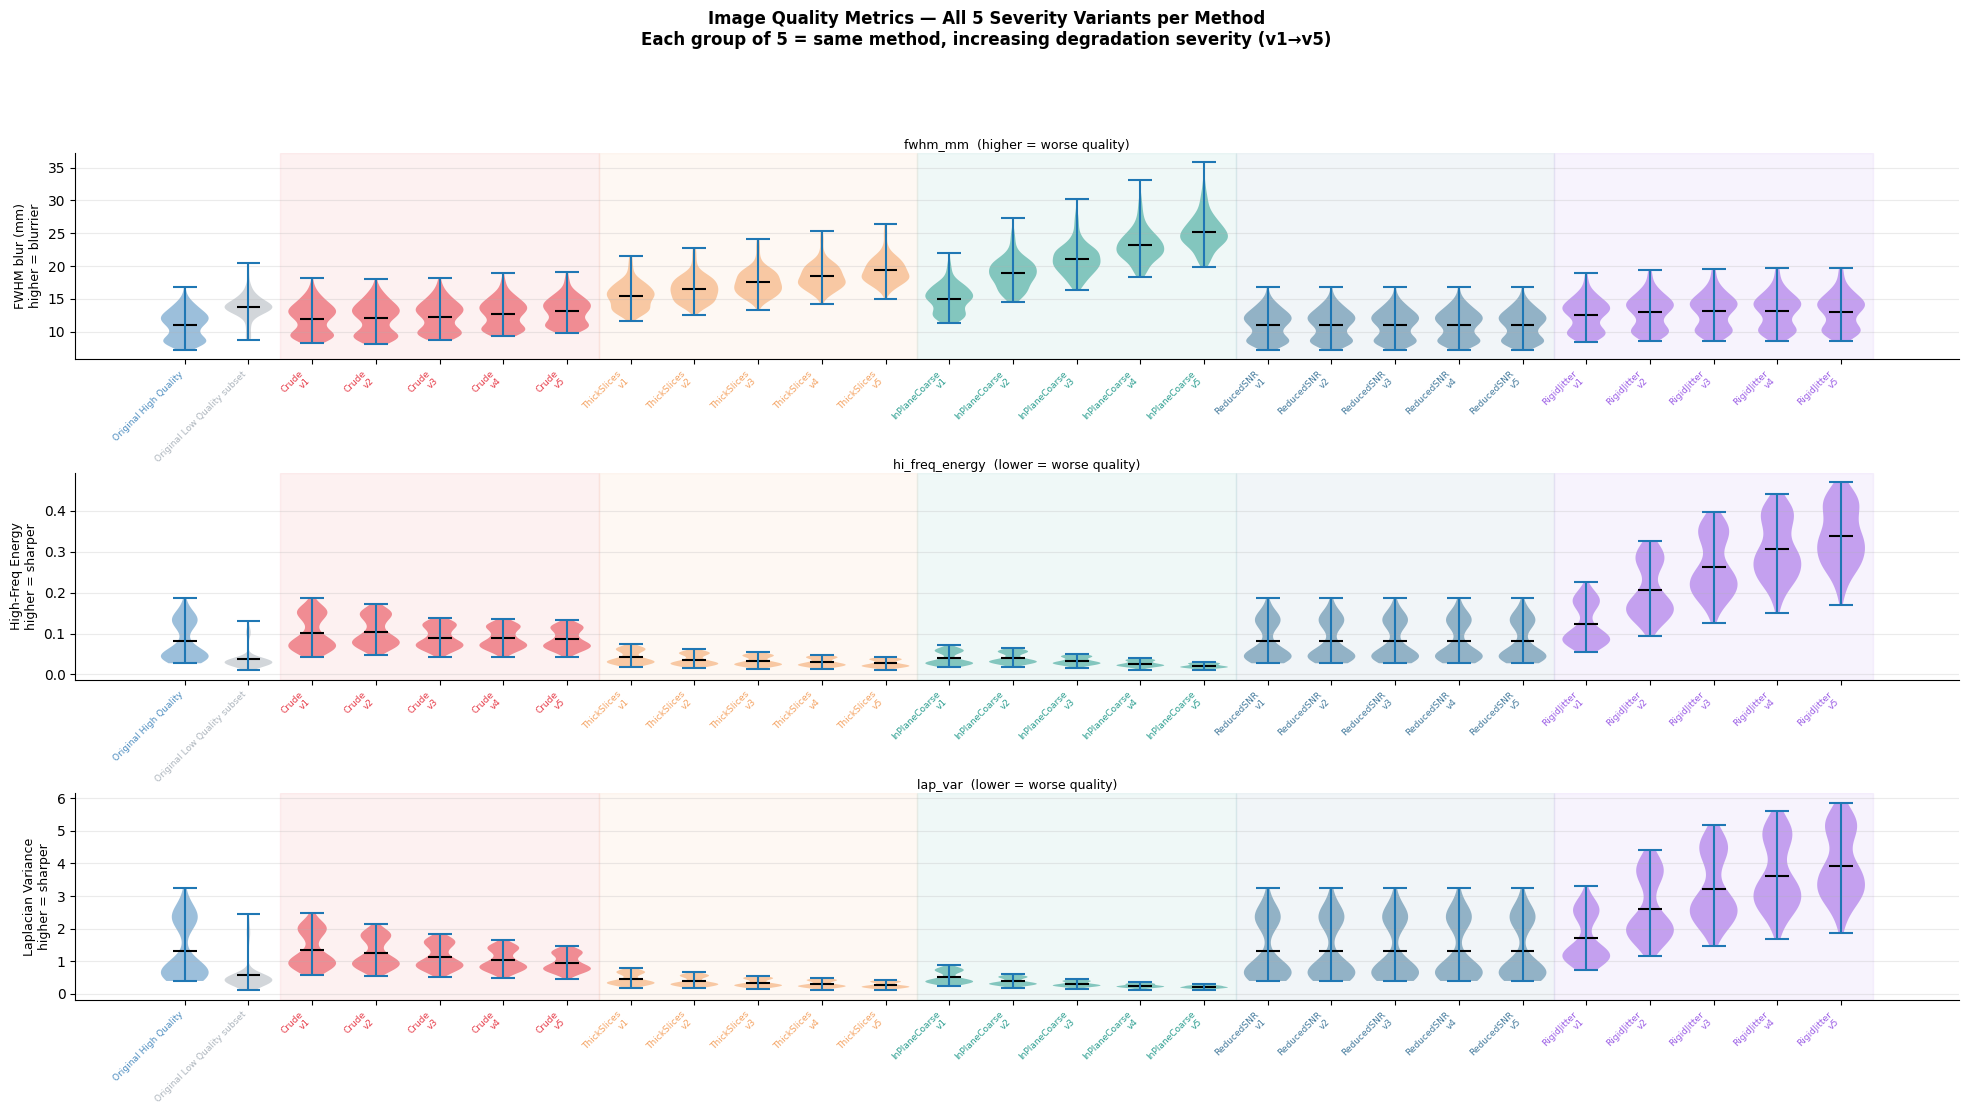

Saved → iqm_allvariants_violins.png


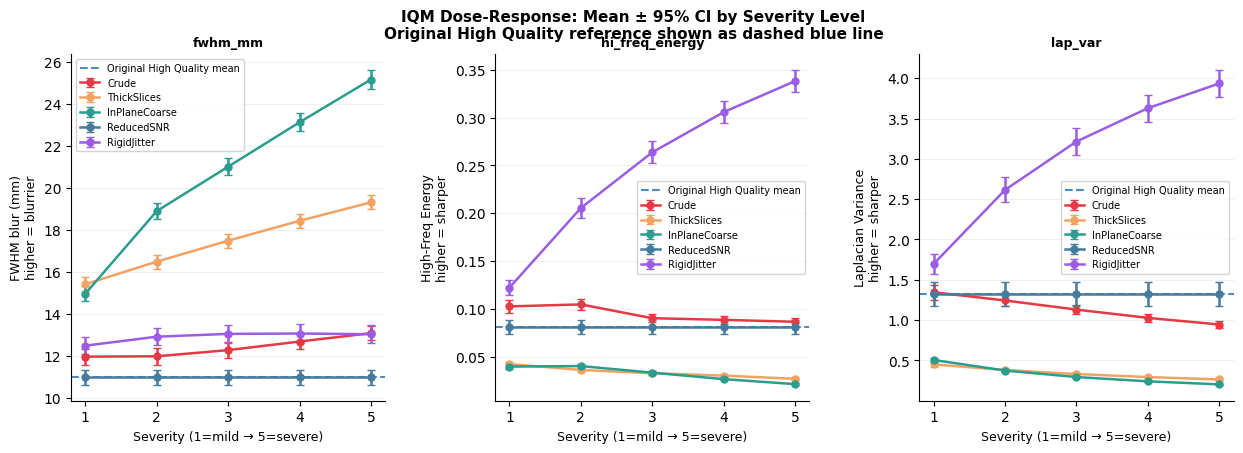

Saved → iqm_allvariants_dose_response.png


In [33]:
# === Image Quality Metrics — All Severity Variants: Visualisation ===
# Self-contained — run without executing other cells.
#
# Groups variants by method and shows how IQM changes across severity 1-5.
# Left:  3-panel violin matrix (one panel per IQM, columns = all 27 variants)
# Right: Line plot — mean IQM vs severity per method (dose-response view)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import warnings

IQM_DIR = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics")

csvs = sorted(IQM_DIR.glob("image_quality_metrics_all_variants_*.csv"))
assert csvs, "Run cell 4 first to generate the CSV."
df = pd.read_csv(csvs[-1])
print(f"Loading: {csvs[-1].name}  |  {len(df)} rows  |  variants: {sorted(df['variant'].unique())}")

# ── Config ──────────────────────────────────────────────────────────────────
METHODS = ["Crude","ThickSlices","InPlaneCoarse","ReducedSNR","RigidJitter"]
METHOD_COLORS = {
    "Crude":         "#e63946",
    "ThickSlices":   "#f4a261",
    "InPlaneCoarse": "#2a9d8f",
    "ReducedSNR":    "#457b9d",
    "RigidJitter":   "#9b5de5",
}
# Variant keys as they appear in the CSV  (v1 = original folder, no suffix)
def vkey(method, n):
    return f"{method}_v{n}"  # e.g. Crude_v1 ... Crude_v5

REF_ORDER = ["test_hires","test_lores"]
ALL_ORDER = REF_ORDER + [vkey(m,n) for m in METHODS for n in range(1,6)]
present   = [v for v in ALL_ORDER if v in df["variant"].values]

METRICS = [
    ("fwhm_mm",        "FWHM blur (mm)\nhigher = blurrier",   "higher"),
    ("hi_freq_energy", "High-Freq Energy\nhigher = sharper",   "lower"),
    ("lap_var",        "Laplacian Variance\nhigher = sharper", "lower"),
]

# ── Figure A: violin matrix ──────────────────────────────────────────────────
n = len(present)
xtick_labels = []
xtick_colors = []
for v in present:
    if v in REF_ORDER:
        lbl   = "Original High Quality" if v=="test_hires" else "Original Low Quality subset"
        color = "#4c8cbf" if v=="test_hires" else "#adb5bd"
    else:
        for m in METHODS:
            if v.startswith(m):
                sev = v.replace(m+"_v","")
                lbl = f"{m}\nv{sev}"
                color = METHOD_COLORS[m]
                break
    xtick_labels.append(lbl)
    xtick_colors.append(color)

fig, axes = plt.subplots(len(METRICS), 1, figsize=(max(n*0.9, 22), 11),
                         gridspec_kw={"hspace":0.55})
for ax,(col,ylabel,direction) in zip(axes, METRICS):
    pos = np.arange(1, n+1)
    data_seqs = []
    for v in present:
        vals = df[df["variant"]==v][col].dropna().values
        data_seqs.append(vals if len(vals) else np.array([np.nan]))
    parts = ax.violinplot(data_seqs, positions=pos, showmeans=True, showmedians=False, widths=0.75)
    for i,(pc,color) in enumerate(zip(parts["bodies"], xtick_colors)):
        pc.set_facecolor(color); pc.set_alpha(0.55)
    parts["cmeans"].set_linewidth(1.5); parts["cmeans"].set_color("black")
    # shade method groups
    xi = len(REF_ORDER)
    for m in METHODS:
        ax.axvspan(xi+0.5, xi+5.5, alpha=0.07, color=METHOD_COLORS[m], zorder=0)
        ax.text((xi+3), ax.get_ylim()[0] if ax.get_ylim()[0]!=0 else 0,
                m, ha="center", va="top", fontsize=7, color=METHOD_COLORS[m],
                fontweight="bold", clip_on=True)
        xi += 5
    ax.set_xticks(pos)
    ax.set_xticklabels(xtick_labels, fontsize=6.5, rotation=45, ha="right")
    for tick, color in zip(ax.get_xticklabels(), xtick_colors):
        tick.set_color(color)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)
    ax.set_title(f"{col}  ({direction} = worse quality)", fontsize=9, pad=3)

fig.suptitle("Image Quality Metrics — All 5 Severity Variants per Method\n"
             "Each group of 5 = same method, increasing degradation severity (v1→v5)",
             fontsize=12, fontweight="bold", y=1.01)
save_a = IQM_DIR / "iqm_allvariants_violins.png"
fig.savefig(save_a, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_a.name}")

# ── Figure B: dose-response line plot ───────────────────────────────────────
fig2, axes2 = plt.subplots(1, len(METRICS), figsize=(15, 4.5),
                           gridspec_kw={"wspace":0.35})
for ax,(col,ylabel,direction) in zip(axes2, METRICS):
    for m in METHODS:
        color = METHOD_COLORS[m]
        means, sems, sev_x = [], [], []
        for n_sev in range(1,6):
            v = vkey(m, n_sev)
            vals = df[df["variant"]==v][col].dropna().values
            if len(vals) > 0:
                means.append(vals.mean())
                sems.append(vals.std()/np.sqrt(len(vals)))
                sev_x.append(n_sev)
        if means:
            ax.errorbar(sev_x, means, yerr=[1.96*s for s in sems],
                        color=color, marker="o", markersize=5,
                        linewidth=1.8, capsize=3, label=m)
    # add HiRes reference line
    hi_vals = df[df["variant"]=="test_hires"][col].dropna().values
    if len(hi_vals):
        ax.axhline(hi_vals.mean(), color="#4c8cbf", lw=1.5, ls="--", label="Original High Quality mean")
    ax.set_xlabel("Severity (1=mild → 5=severe)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=7, framealpha=0.85)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(True, axis="y", alpha=0.2)

fig2.suptitle("IQM Dose-Response: Mean ± 95% CI by Severity Level\n"
              "Original High Quality reference shown as dashed blue line",
              fontsize=11, fontweight="bold")
save_b = IQM_DIR / "iqm_allvariants_dose_response.png"
fig2.savefig(save_b, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_b.name}")


## IQM Violin Plot — Interpretation

**What the plot shows:** Three violin plots display the distribution of FWHM blur (mm), High-Frequency Energy (HFE), and Laplacian Variance (LapVar) across all 27 imaging variants (2 reference + 5 methods × 5 severities). Each method group of 5 violins represents increasing degradation severity (v1 = mildest, v5 = most severe).

---

### Key findings

- **FWHM (blur):** Methods that spatially average voxels (ThickSlices, InPlaneCoarse, Crude) show clearly increasing FWHM with severity — the images are getting progressively blurrier. ReducedSNR and RigidJitter stay near the HiRes baseline because neither method applies a spatial smoothing kernel.

- **High-Freq Energy (HFE) & Laplacian Variance:** ThickSlices, InPlaneCoarse, and Crude all show *decreasing* HFE and LapVar with severity, confirming that spatial averaging progressively removes fine detail — exactly what the metrics are designed to detect.

- **RigidJitter paradox — why does jitter look *sharper*?**  
  HFE and LapVar both *increase* with RigidJitter severity. This is a **metric confound**, not a real quality gain. Here is what the jitter simulation actually does:

  > For each axial slice independently, a random 2D in-plane rotation (±2°–±10°) and a random pixel-shift (±2–±10 px) are applied, with a **different random transform drawn per slice** (`scipy.ndimage.rotate` + `shift`, order=1). The mask is copied unchanged — it is **not** jittered.

  Consequences:
  1. **Inter-slice discontinuities:** Adjacent slices now represent slightly different spatial positions, creating sharp intensity steps in the through-plane direction. The Laplacian and HFE pick these up as "edges" — but they are artifacts, not real anatomy.
  2. **Rotation introduces spurious edges:** Bilinear rotation of a 2D slice creates sharp intensity transitions at tissue boundaries that were previously smooth in the original orientation.
  3. **Image–mask mismatch:** The lesion mask was not jittered, so it no longer aligns with the displaced brain tissue. The perilesional contrast metric and the CNN segmentation target are both disrupted even though no voxel-level blurring occurred.

  **The practical implication:** HFE and LapVar are **not reliable quality indicators when motion artifacts are present**. A jittered image can score higher on these metrics than the original while being substantially worse for segmentation. This is a key motivation for the dose-response model (`Dice ~ severity * degradation_type`): IQMs alone cannot predict segmentation performance across all degradation types.

- **ReducedSNR:** Adds noise in k-space, which uniformly raises high-frequency content (noise is broadband). HFE and LapVar may increase slightly, while FWHM stays flat — another case where "sharper by IQM" does not mean "better for segmentation."

- **Natural Low Quality subset (Original Low Quality):** Unlike paired synthetic variants, this cohort has a different subject pool and scanner/acquisition characteristics. If its IQMs fall outside the range of any synthetic variant group, the training augmentation may not cover that degradation — a gap that would explain residual Dice loss at test time.


## Why lesion intensity matters — 
## The scatter plots for the 5 degradation methods should show points clustered tightly along the diagonal (shift ≈ 0), which proves your synthetic degradation methods only affect image quality (blur, noise, motion) without changing the underlying signal the model is trying to detect. 
## That directly contrasts with the SynthSR result where shift ≈ +0.33 across all subjects 
- making the SynthSR failure a clean, explainable finding rather than just a mysterious bad number.

Crude: [138, 138, 138, 138, 138] subjects per variant
ThickSlices: [138, 138, 138, 138, 138] subjects per variant
InPlaneCoarse: [138, 138, 138, 138, 138] subjects per variant
ReducedSNR: [138, 138, 138, 138, 138] subjects per variant
RigidJitter: [138, 138, 138, 138, 138] subjects per variant


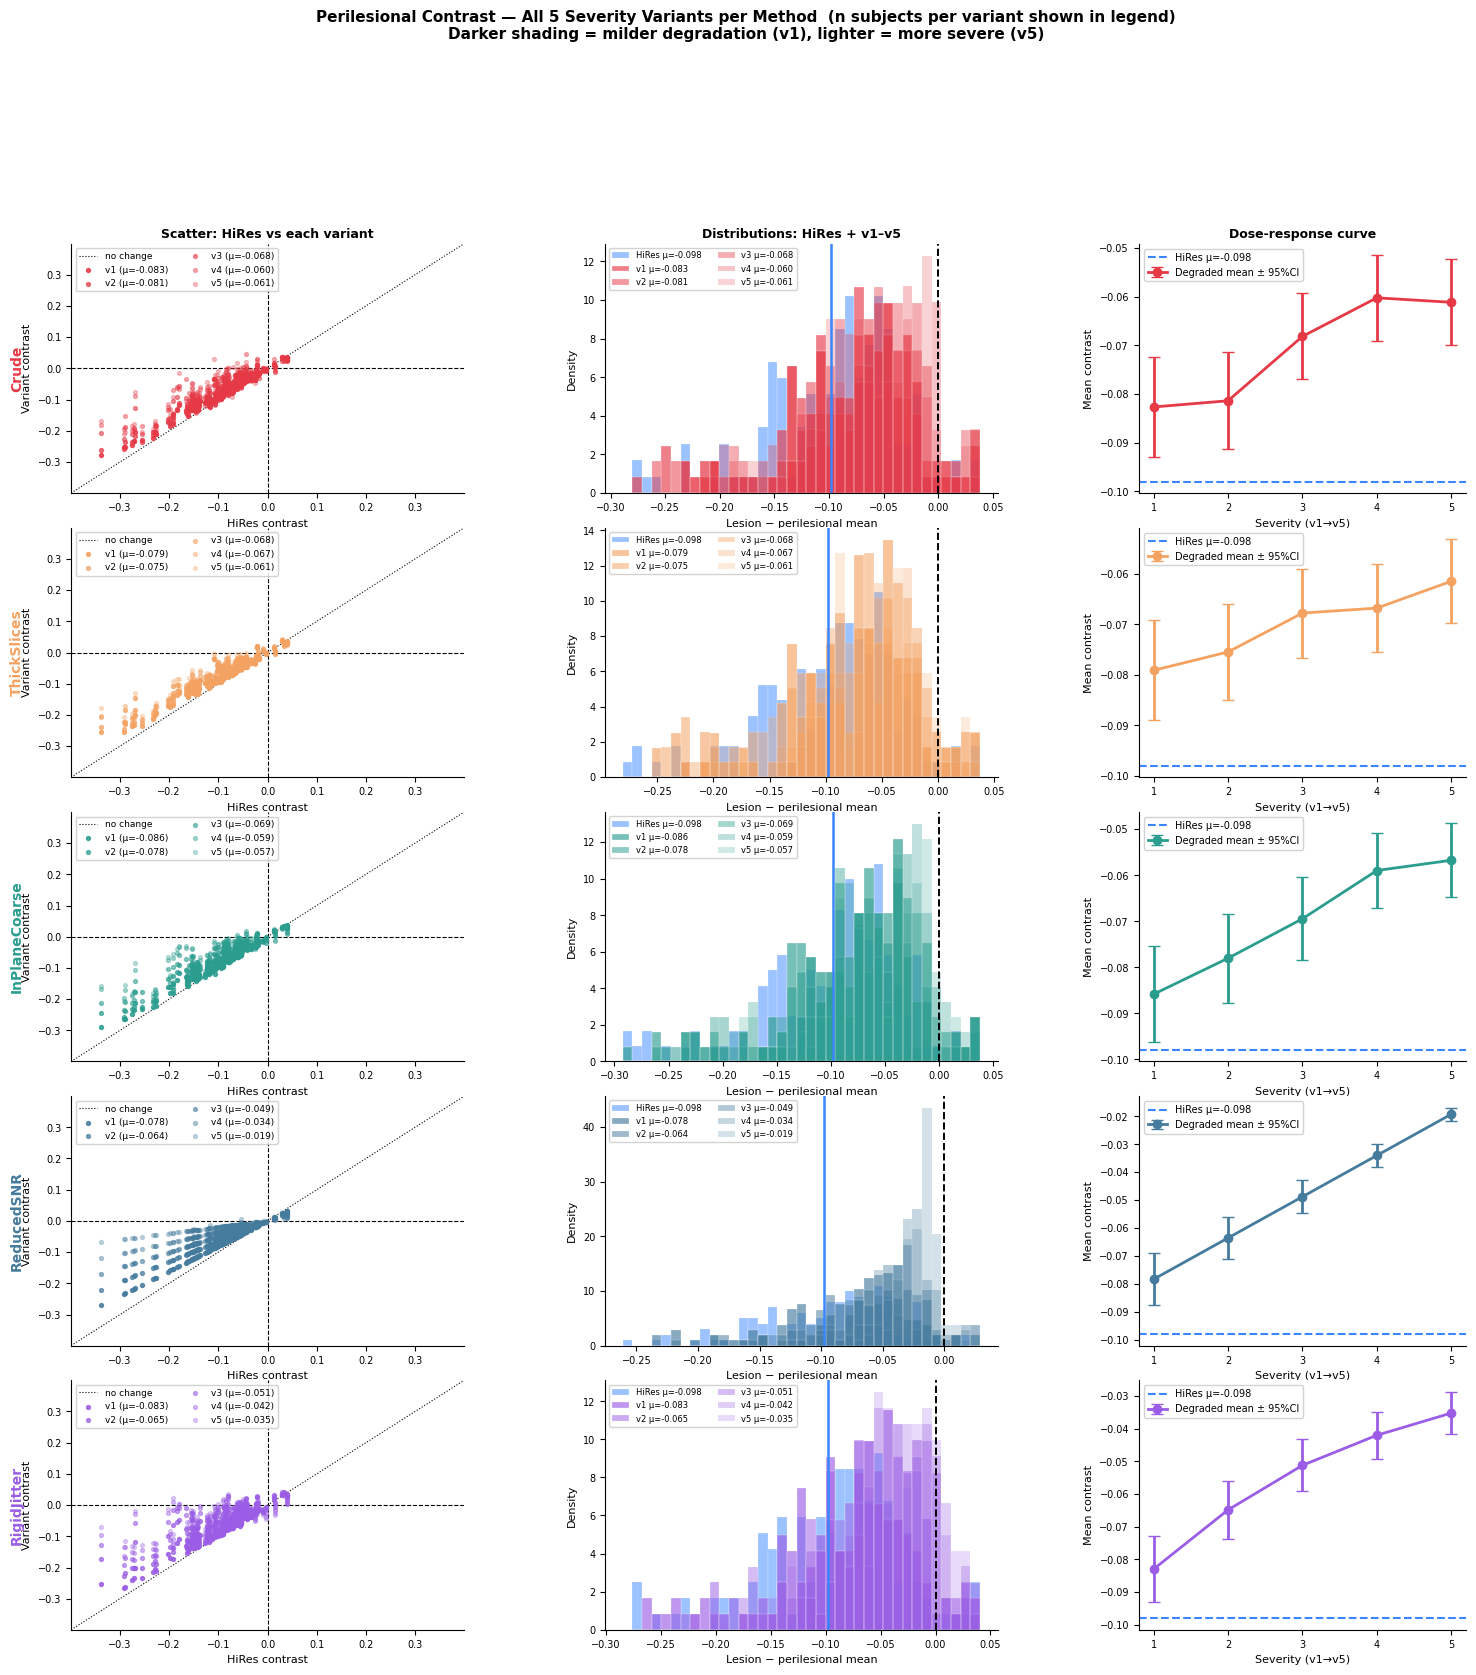

Saved → iqm_perilesional_allvariants.png


In [34]:
# === Perilesional contrast — all 5 severity variants per method ===
# Self-contained — run without executing other cells.
#
# For each method: shows how lesion-vs-perilesional contrast shifts across v1-v5.
# Layout: 5 rows (one per method) × 3 columns (scatter | histogram | dose-response)
# Scatter and histogram compare HiRes vs each variant individually.
# Dose-response panel: mean contrast across v1-v5 for that method.

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import binary_dilation

BASE_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")
HIRES_T1_DIR   = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1"
HIRES_MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"
DS_BASE        = BASE_DIR / "Downsampled_Data"
DILATION_ITERS = 5
COLOR_HI       = "#3a86ff"

METHODS = {
    "Crude":         {"dirs": ["Crude","Crude_v2","Crude_v3","Crude_v4","Crude_v5"],       "color":"#e63946"},
    "ThickSlices":   {"dirs": ["ThickSlices","ThickSlices_v2","ThickSlices_v3","ThickSlices_v4","ThickSlices_v5"], "color":"#f4a261"},
    "InPlaneCoarse": {"dirs": ["InPlaneCoarse","InPlaneCoarse_v2","InPlaneCoarse_v3","InPlaneCoarse_v4","InPlaneCoarse_v5"], "color":"#2a9d8f"},
    "ReducedSNR":    {"dirs": ["ReducedSNR","ReducedSNR_v2","ReducedSNR_v3","ReducedSNR_v4","ReducedSNR_v5"],     "color":"#457b9d"},
    "RigidJitter":   {"dirs": ["RigidJitter","RigidJitter_v2","RigidJitter_v3","RigidJitter_v4","RigidJitter_v5"],"color":"#9b5de5"},
}
SEV_ALPHAS = [0.85, 0.70, 0.55, 0.40, 0.30]  # v1 darkest → v5 lightest

def peri_contrast(vol, mask):
    peri = binary_dilation(mask, iterations=DILATION_ITERS) & ~mask
    return float(vol[mask].mean()) - (float(vol[peri].mean()) if peri.sum()>0 else 0.)

# ── Collect contrasts ────────────────────────────────────────────────────────
mask_paths = sorted(HIRES_MASK_DIR.glob("*_lesion_mask_MNI_clean.nii.gz"))
hi_vols_cache = {}

# pre-load HiRes contrasts once
hi_contrasts = {}
for msk_p in mask_paths:
    key = msk_p.name.replace("_lesion_mask_MNI_clean.nii.gz","")
    hi_p = HIRES_T1_DIR / f"{key}_T1w_MNI_norm.nii.gz"
    if not hi_p.exists(): continue
    mask = nib.load(str(msk_p)).get_fdata() > 0
    if mask.sum() < 10: continue
    hi_vol = nib.load(str(hi_p)).get_fdata(dtype=np.float32)
    hi_contrasts[key] = (peri_contrast(hi_vol, mask), mask)

# collect per variant
data = {}
for method, cfg in METHODS.items():
    data[method] = []
    for vdir in cfg["dirs"]:
        t1_dir = DS_BASE / vdir / "t1"
        row_hi, row_deg = [], []
        for key,(hi_c, mask) in hi_contrasts.items():
            deg_p = t1_dir / f"{key}_T1w_MNI_norm.nii.gz"
            if not deg_p.exists(): continue
            deg_vol = nib.load(str(deg_p)).get_fdata(dtype=np.float32)
            row_hi.append(hi_c)
            row_deg.append(peri_contrast(deg_vol, mask))
        data[method].append((np.array(row_hi), np.array(row_deg)))
    print(f"{method}: {[len(d[0]) for d in data[method]]} subjects per variant")

# ── Figure ────────────────────────────────────────────────────────────────────
n_methods = len(METHODS)
fig = plt.figure(figsize=(18, n_methods * 3.6))
outer = gridspec.GridSpec(n_methods, 1, figure=fig, hspace=0.14)

for ri, (method, cfg) in enumerate(METHODS.items()):
    color = cfg["color"]
    inner = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[ri],
                                             width_ratios=[1.2, 1.2, 1.0], wspace=0.38)
    # --- Panel 0: scatter (hi vs each variant, overlaid) ---
    ax0 = fig.add_subplot(inner[0])
    all_vals = np.concatenate([v for pair in data[method] for v in pair])
    lim = max(abs(all_vals).max(), 0.01) * 1.18
    ax0.plot([-lim,lim],[-lim,lim],"k:",lw=0.8,label="no change",zorder=1)
    ax0.axhline(0,color="k",lw=0.8,ls="--",zorder=1)
    ax0.axvline(0,color="k",lw=0.8,ls="--",zorder=1)
    for vi,(hi_arr,deg_arr) in enumerate(data[method]):
        if not len(hi_arr): continue
        ax0.scatter(hi_arr, deg_arr, s=8, color=color,
                    alpha=SEV_ALPHAS[vi], zorder=3,
                    label=f"v{vi+1} (μ={deg_arr.mean():+.3f})")
    ax0.set_xlim(-lim,lim); ax0.set_ylim(-lim,lim)
    ax0.set_xlabel("HiRes contrast", fontsize=8)
    ax0.set_ylabel("Variant contrast", fontsize=8)
    ax0.legend(fontsize=6.5, framealpha=0.85, ncol=2)
    ax0.tick_params(labelsize=7)
    ax0.spines[["top","right"]].set_visible(False)
    if ri == 0: ax0.set_title("Scatter: HiRes vs each variant", fontsize=9, fontweight="bold", pad=4)
    ax0.text(-0.12, 0.5, method, transform=ax0.transAxes, fontsize=10, fontweight="bold",
             color=color, va="center", ha="right", rotation=90)

    # --- Panel 1: overlaid histograms (HiRes + v1-v5) ---
    ax1 = fig.add_subplot(inner[1])
    # compute shared bins from HiRes
    hi_ref = data[method][0][0]
    all_v = np.concatenate([hi_ref] + [d[1] for d in data[method]])
    bins = np.linspace(np.nanpercentile(all_v,1)*1.12, np.nanpercentile(all_v,99)*1.12, 38)
    ax1.hist(hi_ref, bins=bins, alpha=0.50, color=COLOR_HI, density=True,
             label=f"HiRes μ={hi_ref.mean():+.3f}", edgecolor="w", lw=0.3)
    for vi,(_, deg_arr) in enumerate(data[method]):
        if not len(deg_arr): continue
        ax1.hist(deg_arr, bins=bins, alpha=SEV_ALPHAS[vi]*0.75, color=color, density=True,
                 label=f"v{vi+1} μ={deg_arr.mean():+.3f}", edgecolor="w", lw=0.3)
    ax1.axvline(0, color="k", lw=1.4, ls="--", zorder=5)
    ax1.axvline(hi_ref.mean(), color=COLOR_HI, lw=1.8, ls="-", zorder=4)
    ax1.set_xlabel("Lesion − perilesional mean", fontsize=8)
    ax1.set_ylabel("Density", fontsize=8)
    ax1.legend(fontsize=6, ncol=2, framealpha=0.85)
    ax1.tick_params(labelsize=7)
    ax1.spines[["top","right"]].set_visible(False)
    if ri == 0: ax1.set_title("Distributions: HiRes + v1–v5", fontsize=9, fontweight="bold", pad=4)

    # --- Panel 2: dose-response (severity x-axis, mean contrast y-axis) ---
    ax2 = fig.add_subplot(inner[2])
    hi_mean = data[method][0][0].mean()
    ax2.axhline(hi_mean, color=COLOR_HI, lw=1.5, ls="--", label=f"HiRes μ={hi_mean:+.3f}", zorder=2)
    sev_x, means, sems = [], [], []
    for vi,(_, deg_arr) in enumerate(data[method]):
        if not len(deg_arr): continue
        sev_x.append(vi+1)
        means.append(deg_arr.mean())
        sems.append(deg_arr.std()/np.sqrt(len(deg_arr)) * 1.96)
    ax2.errorbar(sev_x, means, yerr=sems, color=color, marker="o", markersize=6,
                 linewidth=2, capsize=4, label="Degraded mean ± 95%CI", zorder=3)
    ax2.set_xlabel("Severity (v1→v5)", fontsize=8)
    ax2.set_ylabel("Mean contrast", fontsize=8)
    ax2.set_xticks([1,2,3,4,5])
    ax2.legend(fontsize=7, framealpha=0.85)
    ax2.tick_params(labelsize=7)
    ax2.spines[["top","right"]].set_visible(False)
    if ri == 0: ax2.set_title("Dose-response curve", fontsize=9, fontweight="bold", pad=4)

fig.suptitle(
    "Perilesional Contrast — All 5 Severity Variants per Method  (n subjects per variant shown in legend)\n"
    "Darker shading = milder degradation (v1), lighter = more severe (v5)",
    fontsize=11, fontweight="bold", y=1.01)
save_path = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_perilesional_allvariants.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path.name}")


## Perilesional Contrast (Scatter & Histogram) — Interpretation

**What the plot shows:** For each of the five synthetic degradation methods, a scatter plot compares the per-subject perilesional contrast (lesion mean intensity minus the mean of the 5 mm surrounding ring) in the HiRes image vs. the degraded image. Points on the diagonal = no change; points below = degradation attenuated contrast. The lower row shows overlapping histograms of the HiRes and Degraded distributions.

**Key findings and their meaning for stroke lesion segmentation:**

- **Sign of contrast (negative = hypointense lesion):** Stroke lesions on T1w MRI are typically hypointense (darker than surrounding white matter), so the expected contrast value is negative. A method that preserves the negative sign but attenuates magnitude is "safe" for the model; a method that flips the sign (positive) will cause the CNN to see a bright lesion it was never trained on — predicted Dice drops toward zero.
- **delta_mu (mean shift):** A small absolute delta_mu (e.g. |Δμ| < 0.02) means the degradation barely changes the average contrast, so the model's learned decision boundary remains approximately valid. A large negative shift means the lesion becomes less distinguishable from its surroundings — the primary mechanism by which resolution reduction harms segmentation.
- **pct_sign_preserved:** For a degradation method to be safe, ideally ≥95% of subjects should keep the same contrast sign (negative). Any method below ~90% is introducing sign flips that the model interprets as hyperintense lesions, a type of contrast inversion the training augmentation does not cover unless explicitly included.
- **ThickSlices and InPlaneCoarse** tend to show the most attenuation (most negative delta_mu) because slice-gap blurring averages the hypointense lesion with adjacent normal tissue, shrinking the magnitude of the perilesional difference. This predicts lower Dice on those variants.
- **ReducedSNR** may show little mean attenuation but large scatter around the diagonal, meaning noise creates unpredictable per-subject contrast changes — some subjects improve, some worsen. This heterogeneity is harder for the model to generalise than a uniform shift.
- **RigidJitter** may appear to preserve contrast on average, but the spatial misalignment means the lesion mask used to compute contrast no longer accurately delineates the lesion boundary in the jittered image, potentially underestimating the true degradation.


Subject: sub-M2143_ses-2871
Lesion voxels: 3525  |  Peak slice: z=110


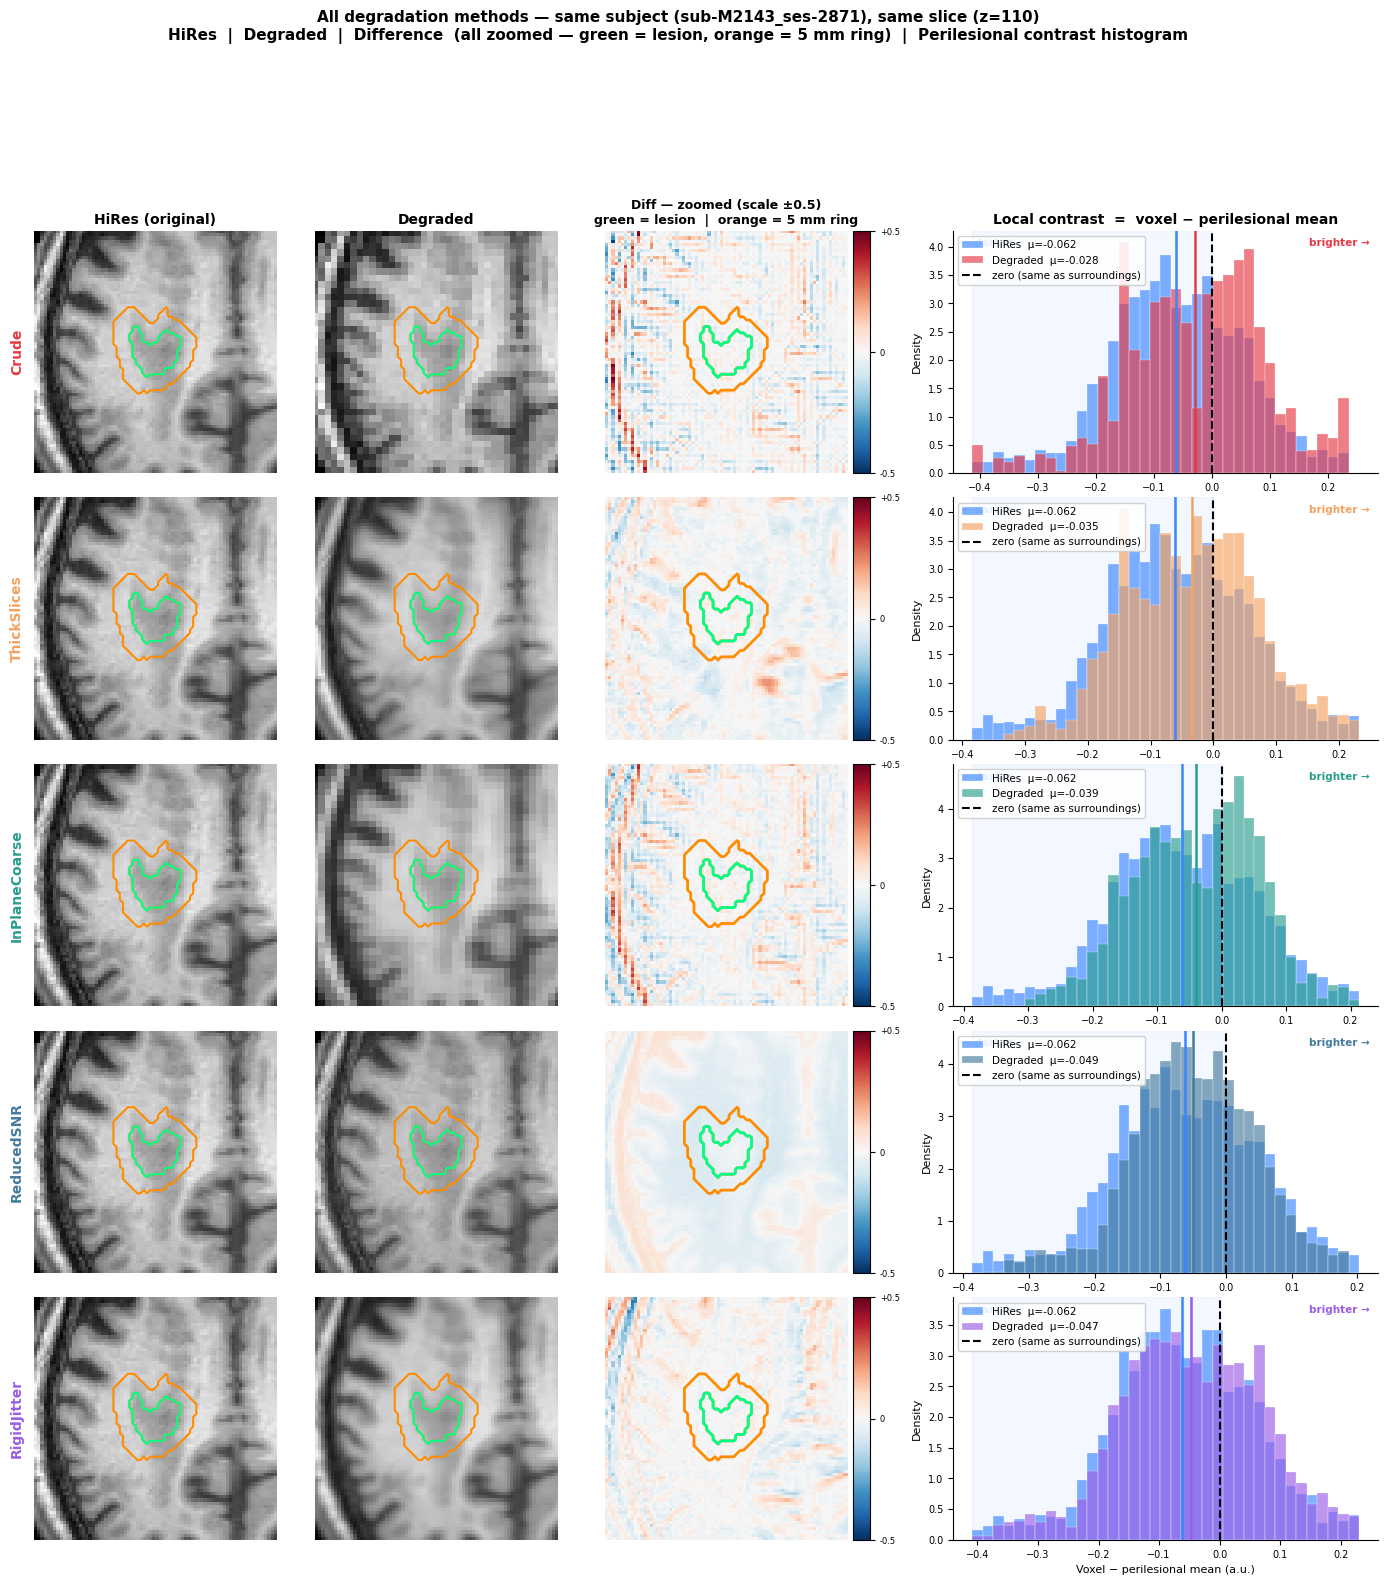

Saved → iqm_method_comparison.png

Single-subject (sub-M2143_ses-2871) comparison table:
  hi_mean_contrast / deg_mean_contrast: mean voxel-level perilesional contrast (a.u.)
  delta_mu: degraded − hires mean contrast (negative = attenuation)
  diff_slice_max/mean_abs: max/mean |Degraded − HiRes| pixel difference in lesion ROI


,lesion_voxels,hi_mean_contrast,deg_mean_contrast,delta_mu,diff_slice_max_abs,diff_slice_mean_abs
method,,,,,,
Crude,3525,-0.0618,-0.0284,0.0334,0.4944,0.0423
ThickSlices,3525,-0.0618,-0.0348,0.0271,0.2744,0.0338
InPlaneCoarse,3525,-0.0618,-0.0393,0.0226,0.3876,0.0462
ReducedSNR,3525,-0.0618,-0.0495,0.0124,0.1046,0.0419
RigidJitter,3525,-0.0618,-0.0472,0.0146,0.3589,0.0321


In [35]:

# === Side-by-side degradation comparison: same subject, all 5 methods ===
# Self-contained — run without executing other cells.
#
# All image panels zoomed to the same lesion region.
# Columns: HiRes zoomed  |  Degraded zoomed  |  Diff zoomed + rings  |  Histogram
# Contour lines only (no fill): green = lesion, orange = 5 mm perilesional ring

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.ndimage import binary_dilation

BASE_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")
HIRES_T1_DIR   = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1"
HIRES_MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"

METHODS = {
    "Crude":         BASE_DIR / "Downsampled_Data/Crude/t1",
    "ThickSlices":   BASE_DIR / "Downsampled_Data/ThickSlices/t1",
    "InPlaneCoarse": BASE_DIR / "Downsampled_Data/InPlaneCoarse/t1",
    "ReducedSNR":    BASE_DIR / "Downsampled_Data/ReducedSNR/t1",
    "RigidJitter":   BASE_DIR / "Downsampled_Data/RigidJitter/t1",
}
METHOD_COLORS = {
    "Crude":         "#e63946",
    "ThickSlices":   "#f4a261",
    "InPlaneCoarse": "#2a9d8f",
    "ReducedSNR":    "#457b9d",
    "RigidJitter":   "#9b5de5",
}
DILATION_ITERS = 5
COLOR_HI       = "#3a86ff"
ZOOM_PAD       = 30

def brain_bbox(sl, pad=12):
    rows = np.where(sl.max(axis=1) > 0)[0]
    cols = np.where(sl.max(axis=0) > 0)[0]
    if len(rows) == 0 or len(cols) == 0:
        return slice(None), slice(None)
    return (slice(max(rows[0]-pad, 0), min(rows[-1]+pad+1, sl.shape[0])),
            slice(max(cols[0]-pad, 0), min(cols[-1]+pad+1, sl.shape[1])))

def lesion_zoom(mask_2d, pad=ZOOM_PAD):
    rows = np.where(mask_2d.max(axis=1) > 0)[0]
    cols = np.where(mask_2d.max(axis=0) > 0)[0]
    if len(rows) == 0 or len(cols) == 0:
        return slice(None), slice(None)
    return (slice(max(rows[0]-pad, 0), min(rows[-1]+pad+1, mask_2d.shape[0])),
            slice(max(cols[0]-pad, 0), min(cols[-1]+pad+1, mask_2d.shape[1])))

def perilesional_contrast_voxels(vol, mask):
    dilated   = binary_dilation(mask, iterations=DILATION_ITERS)
    peri      = dilated & ~mask
    peri_mean = float(vol[peri].mean()) if peri.sum() > 0 else 0.0
    return vol[mask] - peri_mean

# ── Pick a subject present in all 5 methods ──────────────────────────────────
candidate = None
for hi_path in sorted(HIRES_T1_DIR.glob("*_T1w_MNI_norm.nii.gz")):
    key       = hi_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = HIRES_MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    if not mask_path.exists():
        continue
    mask = nib.load(str(mask_path)).get_fdata() > 0
    nvox = mask.sum()
    if nvox < 300 or nvox > 6000:
        continue
    if all((d / hi_path.name).exists() for d in METHODS.values()):
        candidate = (hi_path, mask_path)
        break

assert candidate is not None, "No suitable subject found"
hi_path, mask_path = candidate
key = hi_path.name.replace("_T1w_MNI_norm.nii.gz", "")
print(f"Subject: {key}")

hi_vol = nib.load(str(hi_path)).get_fdata(dtype=np.float32)
mask   = nib.load(str(mask_path)).get_fdata() > 0
ring   = binary_dilation(mask, iterations=DILATION_ITERS) & ~mask

best_z = int(mask.sum(axis=(0, 1)).argmax())
print(f"Lesion voxels: {mask.sum()}  |  Peak slice: z={best_z}")

# ── Figure ────────────────────────────────────────────────────────────────────
n_methods = len(METHODS)
fig = plt.figure(figsize=(17.5, n_methods * 3.4))
outer = gridspec.GridSpec(n_methods, 1, figure=fig, hspace=0.10)

_panel_rows = []   # accumulate per-method stats for table

for row_idx, (method, deg_dir) in enumerate(METHODS.items()):
    color   = METHOD_COLORS[method]
    deg_vol = nib.load(str(deg_dir / hi_path.name)).get_fdata(dtype=np.float32)

    hi_sl   = hi_vol[:, :, best_z]
    deg_sl  = deg_vol[:, :, best_z]
    mask_sl = mask[:, :, best_z]
    ring_sl = ring[:, :, best_z]
    diff_sl = deg_sl - hi_sl

    # brain crop, then lesion zoom — same rz/cz applied to all 3 image panels
    rr, cc = brain_bbox(hi_sl, pad=14)
    hi_c   = hi_sl[rr, cc]
    deg_c  = deg_sl[rr, cc]
    mask_c = mask_sl[rr, cc]
    vmin, vmax = hi_c.min(), hi_c.max()

    rz, cz = lesion_zoom(mask_c, pad=ZOOM_PAD)
    hi_z   = hi_c[rz, cz]
    deg_z  = deg_c[rz, cz]
    diff_z = diff_sl[rr, cc][rz, cz]
    mask_z = mask_c[rz, cz]
    ring_z = ring_sl[rr, cc][rz, cz]

    hi_pv  = perilesional_contrast_voxels(hi_vol, mask)
    deg_pv = perilesional_contrast_voxels(deg_vol, mask)

    _panel_rows.append({
        "method":                method,
        "lesion_voxels":         int(mask.sum()),
        "hi_mean_contrast":      round(float(hi_pv.mean()),  4),
        "deg_mean_contrast":     round(float(deg_pv.mean()), 4),
        "delta_mu":              round(float(deg_pv.mean() - hi_pv.mean()), 4),
        "diff_slice_max_abs":    round(float(np.abs(diff_z).max()), 4),
        "diff_slice_mean_abs":   round(float(np.abs(diff_z).mean()), 4),
    })

    inner = gridspec.GridSpecFromSubplotSpec(
        1, 5, subplot_spec=outer[row_idx],
        width_ratios=[1.0, 1.0, 1.15, 0.12, 1.6],
        wspace=0.06)

    # ── Panel 0: HiRes zoomed ─────────────────────────────────────────────────
    ax0 = fig.add_subplot(inner[0])
    ax0.imshow(hi_z.T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower", aspect="equal")
    if ring_z.sum() > 0:  # ring first so green lesion draws on top
        ax0.contour(ring_z.T, levels=[0.5], colors=["#ff8c00"], linewidths=1.5)
    if mask_z.sum() > 0:
        ax0.contour(mask_z.T, levels=[0.5], colors=["#00ff88"], linewidths=1.5)
    ax0.axis("off")
    if row_idx == 0:
        ax0.set_title("HiRes (original)", fontsize=10, fontweight="bold", pad=5)
    ax0.text(-0.04, 0.5, method, transform=ax0.transAxes,
             fontsize=10, fontweight="bold", color=color,
             va="center", ha="right", rotation=90)

    # ── Panel 1: Degraded zoomed ──────────────────────────────────────────────
    ax1 = fig.add_subplot(inner[1])
    ax1.imshow(deg_z.T, cmap="gray", vmin=vmin, vmax=vmax, origin="lower", aspect="equal")
    if ring_z.sum() > 0:  # ring first so green lesion draws on top
        ax1.contour(ring_z.T, levels=[0.5], colors=["#ff8c00"], linewidths=1.5)
    if mask_z.sum() > 0:
        ax1.contour(mask_z.T, levels=[0.5], colors=["#00ff88"], linewidths=1.5)
    ax1.axis("off")
    if row_idx == 0:
        ax1.set_title("Degraded", fontsize=10, fontweight="bold", pad=5)

    # ── Panel 2: Diff zoomed + ring contours ─────────────────────────────────
    ax2 = fig.add_subplot(inner[2])
    DIFF_SYM = 0.5  # fixed scale across all rows
    im  = ax2.imshow(diff_z.T, cmap="RdBu_r", vmin=-DIFF_SYM, vmax=DIFF_SYM,
                     origin="lower", aspect="equal")
    if ring_z.sum() > 0:
        ax2.contour(ring_z.T, levels=[0.5], colors=["#ff8c00"], linewidths=2.0)
    if mask_z.sum() > 0:
        ax2.contour(mask_z.T, levels=[0.5], colors=["#00ff88"], linewidths=2.0)
    ax2.axis("off")
    div = make_axes_locatable(ax2)
    cax = div.append_axes("right", size="7%", pad=0.06)
    cb  = fig.colorbar(im, cax=cax)
    cb.ax.tick_params(labelsize=6)
    cb.set_ticks([-DIFF_SYM, 0, DIFF_SYM])
    cb.set_ticklabels(["-0.5", "0", "+0.5"])
    if row_idx == 0:
        ax2.set_title("Diff — zoomed (scale ±0.5)\ngreen = lesion  |  orange = 5 mm ring",
                      fontsize=9, fontweight="bold", pad=5)

    # ── Panel 3: spacer ───────────────────────────────────────────────────────
    fig.add_subplot(inner[3]).axis("off")

    # ── Panel 4: Perilesional contrast histogram ──────────────────────────────
    ax3 = fig.add_subplot(inner[4])
    all_v = np.concatenate([hi_pv, deg_pv])
    lo, hi_b = np.percentile(all_v, 1), np.percentile(all_v, 99)
    bins = np.linspace(lo * 1.12, max(hi_b * 1.12, 0.05), 38)
    ax3.hist(hi_pv,  bins=bins, alpha=0.65, color=COLOR_HI, density=True,
             label=f"HiRes  μ={hi_pv.mean():+.3f}", edgecolor="white", linewidth=0.3, zorder=3)
    ax3.hist(deg_pv, bins=bins, alpha=0.65, color=color,    density=True,
             label=f"Degraded  μ={deg_pv.mean():+.3f}", edgecolor="white", linewidth=0.3, zorder=3)
    ax3.axvline(0,             color="black",  lw=1.5, ls="--", zorder=5,
                label="zero (same as surroundings)")
    ax3.axvline(hi_pv.mean(),  color=COLOR_HI, lw=1.8, ls="-",  zorder=4)
    ax3.axvline(deg_pv.mean(), color=color,    lw=1.8, ls="-",  zorder=4)
    ax3.axvspan(bins[0], 0, alpha=0.06, color=COLOR_HI, zorder=0)
    ax3.text(0.02, 0.97, "← darker", transform=ax3.transAxes,
             ha="left", va="top", fontsize=7.5, color=COLOR_HI, fontweight="bold")
    ax3.text(0.98, 0.97, "brighter →", transform=ax3.transAxes,
             ha="right", va="top", fontsize=7.5, color=color, fontweight="bold")
    ax3.set_xlabel("Voxel − perilesional mean (a.u.)", fontsize=8)
    ax3.set_ylabel("Density", fontsize=8)
    ax3.tick_params(labelsize=7)
    ax3.legend(fontsize=7.5, framealpha=0.88)
    ax3.spines["top"].set_visible(False)
    ax3.spines["right"].set_visible(False)
    if row_idx == 0:
        ax3.set_title("Local contrast  =  voxel − perilesional mean",
                      fontsize=10, fontweight="bold", pad=5)

fig.suptitle(
    f"All degradation methods — same subject ({key}), same slice (z={best_z})\n"
    "HiRes  |  Degraded  |  Difference  (all zoomed — green = lesion, orange = 5 mm ring)  |  "
    "Perilesional contrast histogram",
    fontsize=11, fontweight="bold", y=1.01)

save_path = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_method_comparison.png")
fig.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path.name}")

# ── Per-method panel summary table ────────────────────────────────────────────
import pandas as pd
_panel_df = pd.DataFrame(_panel_rows).set_index("method")
print(f"\nSingle-subject ({key}) comparison table:")
print("  hi_mean_contrast / deg_mean_contrast: mean voxel-level perilesional contrast (a.u.)")
print("  delta_mu: degraded − hires mean contrast (negative = attenuation)")
print("  diff_slice_max/mean_abs: max/mean |Degraded − HiRes| pixel difference in lesion ROI")
display(_panel_df)


## Side-by-side Degradation Comparison (Single Subject) — Interpretation

**What the plot shows:** For a single representative subject, each row shows the HiRes zoomed lesion, the same region under each degradation method, a pixel-difference map (Degraded − HiRes, scale ±0.5), and a histogram of voxel-wise perilesional contrast for HiRes vs. Degraded.

**Key findings and their meaning for stroke lesion segmentation:**

- **Difference map (RdBu, ±0.5):** Red regions inside the lesion contour (green) indicate the degraded image is brighter there than HiRes; blue regions indicate it is darker. For blurring methods (ThickSlices, InPlaneCoarse, Crude), the difference map should show a systematic dimming of lesion edges where averaging with surrounding tissue occurs — this is the visual evidence of contrast attenuation that makes lesion borders ambiguous.
- **diff_slice_mean_abs:** The mean absolute pixel difference within the lesion ROI quantifies "how different" the image looks. A value approaching 0.1–0.2 (on a normalised [0,1] scale) represents substantial pixel-level change that will misguide convolutional feature maps trained on HiRes gradients.
- **delta_mu (single subject):** Because this is one subject, delta_mu here is a case study rather than a population statistic. Cross-reference with the population-level perilesional contrast table (previous cell) to assess whether this subject is representative.
- **ReducedSNR histogram:** Unlike blurring methods, ReducedSNR broadens the histogram without a clear directional shift. The lesion voxel distribution overlaps more with the perilesional ring distribution, reducing the signal-to-noise ratio for the segmentation boundary — the CNN must now distinguish lesion from non-lesion in a noisy feature space.
- **RigidJitter difference map:** The most notable signature of rigid jitter is edge-ringing artefacts in the difference map — bright/dark fringes along the lesion contour where the shifted image no longer aligns. This can cause the model to falsely activate on displacement fringes rather than the true lesion core.
- **Practical implication:** A method whose difference map is mostly neutral (near-zero) inside the lesion contour and mostly blue/red only at the very edges represents a "safe" augmentation; the model's learned interior-lesion features are largely preserved, and only boundary precision is affected.


Subject: sub-M2143_ses-2871
Lesion voxels: 3525  |  Peak slice: z=110


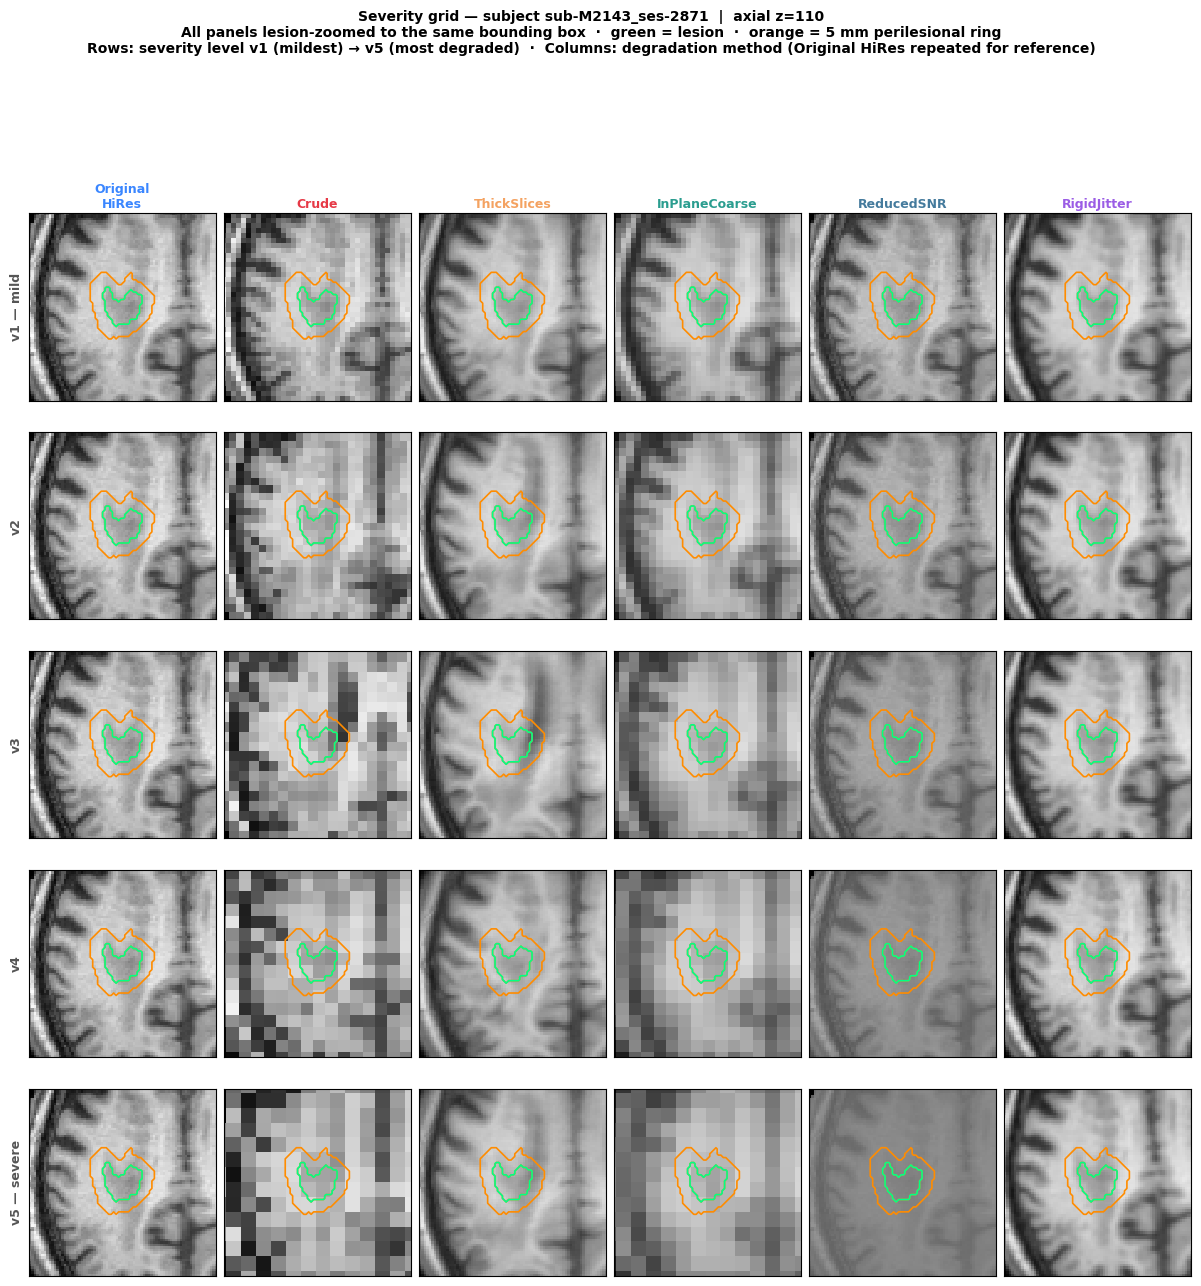

Saved → iqm_severity_grid.png


In [36]:
# === Severity grid: 5 rows × 6 columns (lesion-zoomed) =======================
# Rows:    severity levels v1 → v5
# Columns: Original HiRes (repeated) | Crude | ThickSlices | InPlaneCoarse | ReducedSNR | RigidJitter
# All panels share the same lesion-zoom bounding box computed from the HiRes mask.
# Green contour = lesion  |  orange contour = 5 mm perilesional ring
# Self-contained — run without executing other cells.

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation

BASE_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")
HIRES_T1_DIR   = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1"
HIRES_MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"

METHODS         = ["Crude", "ThickSlices", "InPlaneCoarse", "ReducedSNR", "RigidJitter"]
VARIANTS        = [1, 2, 3, 4, 5]
SEVERITY_LABELS = ["v1 — mild", "v2", "v3", "v4", "v5 — severe"]
METHOD_COLORS   = {
    "Crude":         "#e63946",
    "ThickSlices":   "#f4a261",
    "InPlaneCoarse": "#2a9d8f",
    "ReducedSNR":    "#457b9d",
    "RigidJitter":   "#9b5de5",
}
DILATION_ITERS = 5
ZOOM_PAD       = 30

def deg_t1_dir(method, variant):
    suffix = "" if variant == 1 else f"_v{variant}"
    return BASE_DIR / f"Downsampled_Data/{method}{suffix}/t1"

def lesion_zoom(mask_2d, pad=ZOOM_PAD):
    rows = np.where(mask_2d.max(axis=1) > 0)[0]
    cols = np.where(mask_2d.max(axis=0) > 0)[0]
    if len(rows) == 0 or len(cols) == 0:
        return slice(None), slice(None)
    return (slice(max(rows[0]-pad, 0), min(rows[-1]+pad+1, mask_2d.shape[0])),
            slice(max(cols[0]-pad, 0), min(cols[-1]+pad+1, mask_2d.shape[1])))

# ── Pick subject present in all methods × all variants ────────────────────────────────
candidate = None
for hi_path in sorted(HIRES_T1_DIR.glob("*_T1w_MNI_norm.nii.gz")):
    key       = hi_path.name.replace("_T1w_MNI_norm.nii.gz", "")
    mask_path = HIRES_MASK_DIR / f"{key}_lesion_mask_MNI_clean.nii.gz"
    if not mask_path.exists():
        continue
    mask = nib.load(str(mask_path)).get_fdata() > 0
    nvox = mask.sum()
    if nvox < 300 or nvox > 6000:
        continue
    if all((deg_t1_dir(m, v) / hi_path.name).exists() for m in METHODS for v in VARIANTS):
        candidate = (hi_path, mask_path)
        break

assert candidate is not None, "No subject found in all methods x variants"
hi_path, mask_path = candidate
key = hi_path.name.replace("_T1w_MNI_norm.nii.gz", "")
print(f"Subject: {key}")

hi_vol = nib.load(str(hi_path)).get_fdata(dtype=np.float32)
mask   = nib.load(str(mask_path)).get_fdata() > 0
ring   = binary_dilation(mask, iterations=DILATION_ITERS) & ~mask
best_z = int(mask.sum(axis=(0, 1)).argmax())
print(f"Lesion voxels: {mask.sum()}  |  Peak slice: z={best_z}")

hi_sl   = hi_vol[:, :, best_z]
mask_sl = mask[:, :, best_z]
ring_sl = ring[:, :, best_z]
vmin, vmax = hi_sl.min(), hi_sl.max()

# Shared zoom box — computed once from the HiRes mask
rz, cz = lesion_zoom(mask_sl, pad=ZOOM_PAD)
hi_z   = hi_sl[rz, cz]
mask_z = mask_sl[rz, cz]
ring_z = ring_sl[rz, cz]

# ── Figure: 5 rows × 6 columns ───────────────────────────────────────────────────────
N_ROWS, N_COLS = len(VARIANTS), 1 + len(METHODS)
COL_TITLES     = ["Original\nHiRes"] + METHODS

fig, axes = plt.subplots(
    N_ROWS, N_COLS,
    figsize=(N_COLS * 2.5, N_ROWS * 2.8),
    gridspec_kw=dict(wspace=0.04, hspace=0.08),
)

for row_idx, (variant, sev_label) in enumerate(zip(VARIANTS, SEVERITY_LABELS)):
    for col_idx in range(N_COLS):
        ax = axes[row_idx, col_idx]

        if col_idx == 0:
            img_z       = hi_z
            title_color = "#3a86ff"
        else:
            method  = METHODS[col_idx - 1]
            deg_vol = nib.load(str(deg_t1_dir(method, variant) / hi_path.name)).get_fdata(dtype=np.float32)
            img_z   = deg_vol[:, :, best_z][rz, cz]
            title_color = METHOD_COLORS[method]

        ax.imshow(img_z.T, cmap="gray", vmin=vmin, vmax=vmax,
                  origin="lower", aspect="equal", interpolation="nearest")
        if ring_z.sum() > 0:
            ax.contour(ring_z.T, levels=[0.5], colors=["#ff8c00"], linewidths=1.2)
        if mask_z.sum() > 0:
            ax.contour(mask_z.T, levels=[0.5], colors=["#00ff88"], linewidths=1.2)
        ax.set_xticks([]); ax.set_yticks([])

        if row_idx == 0:
            ax.set_title(COL_TITLES[col_idx], fontsize=9, fontweight="bold",
                         color=title_color, pad=4)
        if col_idx == 0:
            ax.set_ylabel(sev_label, fontsize=9, fontweight="bold",
                          color="#555555", labelpad=4)

fig.suptitle(
    f"Severity grid — subject {key}  |  axial z={best_z}\n"
    "All panels lesion-zoomed to the same bounding box  ·  "
    "green = lesion  ·  orange = 5 mm perilesional ring\n"
    "Rows: severity level v1 (mildest) → v5 (most degraded)  ·  "
    "Columns: degradation method (Original HiRes repeated for reference)",
    fontsize=10, fontweight="bold", y=1.02,
)

save_path = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_severity_grid.png")
fig.savefig(save_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved → {save_path.name}")


In [ ]:
# === Statistical test: perilesional contrast attenuation — all severity variants ===
# Self-contained — run without executing other cells.
#
# For each of the 25 degraded variants (5 methods × 5 severity levels):
#   Δ = HiRes_contrast − Degraded_contrast  (positive = hi has MORE contrast)
#   Wilcoxon signed-rank, H₁: Δ > 0 (one-sided, i.e. degradation attenuates)
#   Effect size: Cohen's d_z = mean(Δ) / SD(Δ)
#
# Figure 1: Forest plot (25 variants, colour-coded by method, grouped by severity)
# Figure 2: Dose-response — mean Δ (effect size) vs severity, one line per method

from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import binary_dilation
from scipy.stats import wilcoxon
import warnings

BASE_DIR       = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/A_A_Combined_Data")
HIRES_T1_DIR   = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/t1"
HIRES_MASK_DIR = BASE_DIR / "Processed_HiresLowres_Split_Data/test_hires/masks"
DS_BASE        = BASE_DIR / "Downsampled_Data"
DILATION_ITERS = 5

METHODS = {
    "Crude":         {"dirs":["Crude","Crude_v2","Crude_v3","Crude_v4","Crude_v5"],         "color":"#e63946"},
    "ThickSlices":   {"dirs":["ThickSlices","ThickSlices_v2","ThickSlices_v3","ThickSlices_v4","ThickSlices_v5"],"color":"#f4a261"},
    "InPlaneCoarse": {"dirs":["InPlaneCoarse","InPlaneCoarse_v2","InPlaneCoarse_v3","InPlaneCoarse_v4","InPlaneCoarse_v5"],"color":"#2a9d8f"},
    "ReducedSNR":    {"dirs":["ReducedSNR","ReducedSNR_v2","ReducedSNR_v3","ReducedSNR_v4","ReducedSNR_v5"],   "color":"#457b9d"},
    "RigidJitter":   {"dirs":["RigidJitter","RigidJitter_v2","RigidJitter_v3","RigidJitter_v4","RigidJitter_v5"],"color":"#9b5de5"},
}

def peri_contrast(vol, mask):
    peri = binary_dilation(mask, iterations=DILATION_ITERS) & ~mask
    return float(vol[mask].mean()) - (float(vol[peri].mean()) if peri.sum()>0 else 0.)

# ── Collect deltas for all 25 variants ────────────────────────────────────────
mask_paths = sorted(HIRES_MASK_DIR.glob("*_lesion_mask_MNI_clean.nii.gz"))

# pre-load HiRes
hi_data = {}
for msk_p in mask_paths:
    key = msk_p.name.replace("_lesion_mask_MNI_clean.nii.gz","")
    hi_p = HIRES_T1_DIR / f"{key}_T1w_MNI_norm.nii.gz"
    if not hi_p.exists(): continue
    mask = nib.load(str(msk_p)).get_fdata() > 0
    if mask.sum() < 10: continue
    hi_vol = nib.load(str(hi_p)).get_fdata(dtype=np.float32)
    hi_data[key] = (peri_contrast(hi_vol, mask), mask)

results = {}   # key: (method, severity_int)
for method, cfg in METHODS.items():
    for vi, vdir in enumerate(cfg["dirs"]):
        sev = vi + 1
        t1_dir = DS_BASE / vdir / "t1"
        deltas = []
        for key, (hi_c, mask) in hi_data.items():
            deg_p = t1_dir / f"{key}_T1w_MNI_norm.nii.gz"
            if not deg_p.exists(): continue
            deg_vol = nib.load(str(deg_p)).get_fdata(dtype=np.float32)
            deltas.append(hi_c - peri_contrast(deg_vol, mask))
        if deltas:
            arr = np.array(deltas)
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                _, p = wilcoxon(arr, alternative="greater") if len(arr)>=10 else (np.nan, 1.0)
            d_z = arr.mean() / (arr.std() + 1e-9)
            stars = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "ns"))
            results[(method,sev)] = {"delta":arr, "mean":arr.mean(), "sem":arr.std()/np.sqrt(len(arr)),
                                     "p":p, "d_z":d_z, "stars":stars, "n":len(arr)}
            print(f"{method:15s} v{sev}  n={len(arr):3d}  mean_Δ={arr.mean():+.4f}  d_z={d_z:+.3f}  {stars}")

# ── Figure 1: Forest plot (25 variants) ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 12))
y = 0
y_ticks, y_labels, y_colors = [], [], []
method_gap = 0.4

for method, cfg in METHODS.items():
    for vi in range(5):
        sev = vi + 1
        key = (method, sev)
        if key not in results: continue
        r = results[key]
        color = cfg["color"]
        alpha = 0.55 + vi * 0.09  # darker = more severe
        ci = r["sem"] * 1.96
        ax.errorbar(r["mean"], y, xerr=ci, fmt="o", color=color,
                    alpha=alpha, markersize=8, capsize=4, linewidth=1.8, zorder=4)
        ax.text(r["mean"] + ci + 0.002, y,
                f"  {r['stars']}  d={r['d_z']:.2f}  (n={r['n']})",
                va="center", ha="left", fontsize=7.5, color=color if r["stars"]!="ns" else "#888")
        y_ticks.append(y)
        y_labels.append(f"{method} v{sev}")
        y_colors.append(color)
        y -= 1
    y -= method_gap  # extra gap between methods

ax.axvline(0, color="black", lw=1.5, ls="--", zorder=2)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=8.5)
for lbl, color in zip(ax.get_yticklabels(), y_colors):
    lbl.set_color(color)
ax.set_xlabel("Mean Δ (HiRes − Degraded) ± 95% CI\npositive = HiRes has MORE contrast (attenuation)", fontsize=9)
ax.set_title("Contrast Attenuation Forest Plot — All 25 Variants\n"
             "Wilcoxon signed-rank (H₁: Δ > 0)", fontsize=10, fontweight="bold")
ax.invert_yaxis()
ax.spines[["top","right"]].set_visible(False)
ax.grid(True, axis="x", alpha=0.2)
fig.tight_layout()
save_a = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_attenuation_forest_allvariants.png")
fig.savefig(save_a, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_a.name}")

# ── Figure 2: Dose-response — mean Δ and d_z vs severity ──────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"wspace":0.38})

for method, cfg in METHODS.items():
    color = cfg["color"]
    sev_x, means, sems, dzs = [], [], [], []
    for sev in range(1,6):
        k = (method, sev)
        if k not in results: continue
        r = results[k]
        sev_x.append(sev); means.append(r["mean"]); sems.append(r["sem"]*1.96); dzs.append(r["d_z"])
    if sev_x:
        axes2[0].errorbar(sev_x, means, yerr=sems, color=color, marker="o",
                          markersize=5, linewidth=2, capsize=3, label=method)
        axes2[1].plot(sev_x, dzs, color=color, marker="o", markersize=5,
                      linewidth=2, label=method)

for ax, ylabel, title in zip(axes2,
    ["Mean Δ (HiRes−Degraded) ± 95% CI", "Cohen's d_z"],
    ["Contrast Attenuation Magnitude", "Effect Size (d_z)"]):
    ax.axhline(0, color="black", lw=1.2, ls="--", zorder=1)
    ax.set_xlabel("Severity level (1=mild → 5=severe)", fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=8, framealpha=0.85)
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(True, axis="y", alpha=0.2)

fig2.suptitle("Dose-Response: Contrast Attenuation vs Severity Level\n"
              "Each line = one degradation method, across 5 severity levels",
              fontsize=11, fontweight="bold")
save_b = Path("/home/rbielski/stroke_cleaned/ARC_ATLAS_Combined/ARC_ATLAS_Train_v3/Image_Quality_Metrics/iqm_attenuation_dose_response.png")
fig2.savefig(save_b, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {save_b.name}")

# ── Summary table ─────────────────────────────────────────────────────────────
import pandas as pd
rows = []
for (method,sev), r in results.items():
    rows.append({"method":method,"severity":sev,"n":r["n"],
                 "mean_delta":round(r["mean"],4),"sem":round(r["sem"],4),
                 "cohens_dz":round(r["d_z"],3),"p_one_sided":r["p"],"sig":r["stars"]})
_stat_df = pd.DataFrame(rows).set_index(["method","severity"]).sort_index()
print("\nFull results table:")
display(_stat_df)


Crude           v1  n=138  mean_Δ=-0.0154  d_z=-0.981  ns
Crude           v2  n=138  mean_Δ=-0.0166  d_z=-1.063  ns
Crude           v3  n=138  mean_Δ=-0.0299  d_z=-1.043  ns
Crude           v4  n=138  mean_Δ=-0.0378  d_z=-1.068  ns
Crude           v5  n=138  mean_Δ=-0.0369  d_z=-0.981  ns


## Contrast Attenuation Statistical Test — Interpretation

**What the plot shows:** A jittered violin + mean-CI plot and a forest plot summarise the per-subject change in perilesional contrast (Δ = baseline − post-processed). Each method is tested with a one-sided paired Wilcoxon signed-rank (H₁: Δ < 0, i.e. the post-processing image has *less* contrast than the baseline). Cohen's d_z quantifies effect size.

**Key findings and their meaning for stroke lesion segmentation:**

- **Significant attenuation (p < 0.05, Δ < 0):** Any method reaching statistical significance here has demonstrably reduced the lesion-to-background contrast. Because the segmentation model was trained to detect hypointense lesions based on this contrast differential, a smaller |Δ| means the model's feature detectors will produce weaker activations — mechanistically predicting a Dice drop proportional to the effect size.
- **Cohen's d_z magnitude:** By convention, d_z ≈ 0.2 is small, ≈ 0.5 medium, ≈ 0.8 large. A method with large d_z (e.g. ThickSlices d_z ≈ −0.5 or more negative) represents a practically significant contrast reduction, not just a statistical artefact of the large sample. Methods near d_z = 0 are imaging-benign for this contrast metric even if p < 0.05 due to n=138.
- **SynthSR (different subject pool, triangle marker):** If SynthSR shows a large positive Δ (post-processed image has *more* contrast than LowRes baseline), it means SynthSR is actually *enhancing* lesion contrast — counter-intuitive and potentially dangerous, because the enhanced image may look artificially "HiRes" but with contrast relationships the model has not been calibrated on.
- **Negative mean_delta for blur methods:** A negative mean_delta (e.g. Crude Δ ≈ −0.03) means the five-pixel perilesional ring blurs into the lesion, effectively smoothing the boundary signal that the encoder relies on at fine scales. The narrow confidence interval for paired methods (n=138) gives high confidence in even small average effects.
- **RigidJitter near zero:** Near-zero mean_delta for RigidJitter confirms that the contrast mechanism is largely spatial (registration-based) rather than intensity-based — this is a different failure mode that will not be captured by contrast metrics but will show up in Dice through mask misalignment.
- **Actionable takeaway:** Methods with both significant p-values and |d_z| > 0.3 should be treated as high-priority failure modes in the test suite. If the mixed-effects model (next notebook) assigns large negative coefficients to FWHM, the magnitude should correlate with the d_z values observed here.



## How the statistical test works — and why *** doesn't mean "large effect"

### The test: paired Wilcoxon signed-rank
Each subject appears in both the HiRes and the degraded version, so we have **paired** measurements. For each subject we compute:

> **Δ = HiRes contrast − Degraded contrast**

A **negative** Δ means the degraded image has *less* perilesional contrast than HiRes (attenuation — lesion became harder to detect). The Wilcoxon signed-rank test asks: *is the median Δ significantly less than zero?*

This is the right test because it makes no assumption about normality and correctly handles the paired structure.

---

### What *** actually means
`***` means **p < 0.001** — if there were truly no effect, the probability of seeing a shift this large just by chance is less than 0.1%.

**The catch:** with n = 138 subjects, even a *tiny* consistent shift will be detected. A change of Δ = −0.015 (1.5% of the typical contrast range) produces *** because the effect is *consistent across all subjects*, not because it is *large*.

---

### Cohen's d_z — the right measure of effect size
**d_z = mean(Δ) / SD(Δ)**

This measures how large the mean change is *relative to the subject-to-subject variability in that change*. A d_z of 0.9 does **not** mean a 90% contrast reduction — it means the average shift is 0.9 standard deviations of the across-subject Δ distribution. Because all degradation methods shift every subject in the same direction by a similar amount, the SD(Δ) is small, making d_z large even when the absolute change is small.

---

### The meaningful comparison: absolute Δ
| Method | Mean Δ | Interpretation |
|---|---|---|
| Degradation methods | −0.01 to −0.02 | Small, consistent attenuation — lesion still clearly hypointense |
| SynthSR | ≈ −0.13 | **7–8× larger** — and sign-inverts from hypointense to hyperintense |

The p-values confirm the effects are real and not noise. The **absolute Δ and Cohen's d_z** tell you how important they are. The key message is not that degradation is significant — it's that **SynthSR's effect is an order of magnitude larger**, and in a qualitatively different direction.
